# 04 — Cohort-scale leakage-free baselines + SBI readiness

The previous notebooks established the following sequence:

- **Notebook 00** loaded heterogeneous clinical trial data into canonical observation, dose, and covariate tables.
- **Notebook 01** showed that retrospective model improvements do not automatically become held-out predictive improvements.
- **Notebook 02** showed that one-step rolling-origin prediction is dominated by empirical baselines, especially LOCF.
- **Notebook 03** showed that calibrated uncertainty is the right next question, but the first probabilistic calibration used global residual pools.

This notebook is the next useful checkpoint before synthetic SBI.

The goal is to answer:

> Across the broader canonical cohort, what is the strongest **deployable, leakage-free** empirical forecasting baseline, and which patient/drug/study strata are suitable for SBI experiments?

This notebook therefore does **not** fit expensive mechanistic ODEs. Instead, it builds the official baseline that future mechanistic/SBI models must beat.

Main outputs:

1. A broad patient feature table across all loaded studies.
2. Rolling-origin empirical forecasts for eligible patients.
3. Leave-one-patient-out and stratified residual calibration.
4. Coverage, NLL, interval-width, and RMSE summaries.
5. Study/drug/arm readiness tables for deciding where SBI should start.
6. A JSON conclusion file with recommended next steps.

In [1]:
from __future__ import annotations

import json
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

# ---------------------------------------------------------------------
# Robust project/output path detection
# ---------------------------------------------------------------------

START = Path.cwd().resolve()


def find_project_root(start: Path) -> Path:
    candidates = [start, *start.parents]

    for p in candidates:
        if (p / "outputs" / "notebook_00_audit_and_fit" / "ALL_observations.csv").exists():
            return p

    for p in candidates:
        if (p / "data").exists() and (p / "outputs").exists():
            return p

    for p in candidates:
        if (p / "pyproject.toml").exists():
            return p

    return start


PROJECT_ROOT = find_project_root(START)

DISCOVERY_OUT_DIR = PROJECT_ROOT / "outputs" / "notebook_00_audit_and_fit"
HOLDOUT_OUT_DIR = PROJECT_ROOT / "outputs" / "notebook_01_holdout_validation"
ROLLING_OUT_DIR = PROJECT_ROOT / "outputs" / "notebook_02_rolling_origin"
PROB_OUT_DIR = PROJECT_ROOT / "outputs" / "notebook_03_probabilistic_forecasting"

OUT_DIR = PROJECT_ROOT / "outputs" / "notebook_04_cohort_scale_baselines"
PLOT_DIR = OUT_DIR / "plots"

OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print("START:            ", START)
print("PROJECT_ROOT:     ", PROJECT_ROOT)
print("DISCOVERY_OUT_DIR:", DISCOVERY_OUT_DIR)
print("OUT_DIR:          ", OUT_DIR)

START:             C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\notebooks
PROJECT_ROOT:      C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd
DISCOVERY_OUT_DIR: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_00_audit_and_fit
OUT_DIR:           C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_04_cohort_scale_baselines


In [2]:
# ---------------------------------------------------------------------
# Load canonical clinical tables from notebook 00
# ---------------------------------------------------------------------

obs_path = DISCOVERY_OUT_DIR / "ALL_observations.csv"
dose_path = DISCOVERY_OUT_DIR / "ALL_doses.csv"
cov_path = DISCOVERY_OUT_DIR / "ALL_covariates.csv"

if not obs_path.exists():
    raise FileNotFoundError(f"Missing {obs_path}. Run notebook 00 first.")

if not dose_path.exists():
    raise FileNotFoundError(f"Missing {dose_path}. Run notebook 00 first.")

all_observations = pd.read_csv(obs_path, dtype={"patient_id": str, "study_id": str})
all_doses = pd.read_csv(dose_path, dtype={"patient_id": str, "study_id": str})

if cov_path.exists():
    all_covariates = pd.read_csv(cov_path, dtype={"patient_id": str, "study_id": str})
else:
    all_covariates = pd.DataFrame(columns=["study_id", "patient_id"])

for df in [all_observations, all_doses, all_covariates]:
    if "patient_id" in df.columns:
        df["patient_id"] = df["patient_id"].astype(str).str.strip()
    if "study_id" in df.columns:
        df["study_id"] = df["study_id"].astype(str).str.strip()

print("Observations:", all_observations.shape)
print("Doses:       ", all_doses.shape)
print("Covariates:  ", all_covariates.shape)

display(all_observations.head())
display(all_doses.head())

Observations: (28562, 9)
Doses:        (352854, 8)
Covariates:   (6463, 6)


,study_id,patient_id,raw_day,time_days,sld_mm,rel_sld,baseline_sld_mm,n_lesions,arm
0,A6181122,A6181122 1,-10.0,-11.0,99.0,1.000000,99.0,3,NaN
1,A6181122,A6181122 1,41.0,40.0,101.0,1.020202,99.0,3,NaN
2,A6181122,A6181122 1,89.0,88.0,104.0,1.050505,99.0,3,NaN
3,A6181122,A6181122 2,-13.0,-14.0,110.0,1.000000,110.0,7,NaN
4,A6181122,A6181122 2,53.0,52.0,104.0,0.945455,110.0,7,NaN


,study_id,patient_id,raw_day,time_days,drug,dose_amount,dose_unit,arm
0,A6181122,A6181122 1,1.0,0.0,Fluorouracil,832.0,NaN,NaN
1,A6181122,A6181122 1,1.0,0.0,Fluorouracil,4992.0,NaN,NaN
2,A6181122,A6181122 1,1.0,0.0,Folinic Acid/Vitamin K,416.0,NaN,NaN
3,A6181122,A6181122 1,1.0,0.0,Irinotecan,374.0,NaN,NaN
4,A6181122,A6181122 1,1.0,0.0,Placebo,0.0,NaN,NaN


In [3]:
# ---------------------------------------------------------------------
# Optional: load previous conclusions for context
# ---------------------------------------------------------------------

def load_json_if_exists(path: Path) -> dict:
    if path.exists():
        with open(path, "r") as f:
            return json.load(f)
    return {}

previous_conclusions = {
    "holdout": load_json_if_exists(HOLDOUT_OUT_DIR / "holdout_validation_conclusion.json"),
    "rolling_origin": load_json_if_exists(ROLLING_OUT_DIR / "rolling_origin_conclusion.json"),
    "probabilistic": load_json_if_exists(PROB_OUT_DIR / "probabilistic_forecasting_conclusion.json"),
}

print("Previous conclusions found:")
for k, v in previous_conclusions.items():
    print(f"  {k}: {'yes' if v else 'no'}")

if previous_conclusions["rolling_origin"]:
    print("\nNotebook 02 rolling-origin conclusion:")
    print(json.dumps(previous_conclusions["rolling_origin"], indent=2)[:4000])

if previous_conclusions["probabilistic"]:
    print("\nNotebook 03 probabilistic conclusion:")
    print(json.dumps(previous_conclusions["probabilistic"], indent=2)[:4000])

Previous conclusions found:
  holdout: yes
  rolling_origin: yes
  probabilistic: no

Notebook 02 rolling-origin conclusion:
{
  "n_patients": 20,
  "min_train_scans": 6,
  "summary_by_model": [
    {
      "model": "LOCF",
      "count": 134,
      "median_abs_log_error": 0.04573570174857963,
      "mean_abs_log_error": 0.10181848143713808,
      "rmse_one_step": 0.18460307659749378,
      "median_pred_rel_sld": 0.5555555555555556
    },
    {
      "model": "RecentLogSlope",
      "count": 134,
      "median_abs_log_error": 0.06555913706039254,
      "mean_abs_log_error": 0.12738957233407114,
      "rmse_one_step": 0.20969416413610806,
      "median_pred_rel_sld": 0.5346509188985551
    },
    {
      "model": "LogLinear",
      "count": 134,
      "median_abs_log_error": 0.24290943256188974,
      "mean_abs_log_error": 0.29457718267057686,
      "rmse_one_step": 0.3762582003260632,
      "median_pred_rel_sld": 0.4236145377503199
    },
    {
      "model": "NestedResistantSimeoni_pl

## Patient-level feature table

Before doing more modeling, we need to know which parts of the loaded clinical tree are actually useful for forecasting and later SBI.

For each patient we compute:

- number of usable scan times;
- follow-up duration;
- scan gap statistics;
- baseline tumor burden;
- best response and final relative SLD;
- dose availability;
- drug signature;
- treatment arm;
- rough response class.

This table becomes the cohort map for all later work.

In [4]:
# ---------------------------------------------------------------------
# Patient feature engineering
# ---------------------------------------------------------------------

def _safe_numeric(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce")


def _clean_string_series(s: pd.Series) -> pd.Series:
    return s.astype(str).str.strip().replace({"": np.nan, "nan": np.nan, "None": np.nan})


def collapse_patient_observations(p_obs: pd.DataFrame) -> pd.DataFrame:
    # Keep positive relative SLD rows, collapse duplicate time_days by median, and sort by time.
    df = p_obs.copy()

    df["time_days"] = _safe_numeric(df["time_days"])
    df["rel_sld"] = _safe_numeric(df["rel_sld"])

    if "sld_mm" in df.columns:
        df["sld_mm"] = _safe_numeric(df["sld_mm"])
    else:
        df["sld_mm"] = np.nan

    if "baseline_sld_mm" in df.columns:
        df["baseline_sld_mm"] = _safe_numeric(df["baseline_sld_mm"])
    else:
        df["baseline_sld_mm"] = np.nan

    df = df[
        df["time_days"].notna()
        & df["rel_sld"].notna()
        & (df["rel_sld"] > 0)
    ].copy()

    if df.empty:
        return df

    agg = {
        "rel_sld": ("rel_sld", "median"),
        "sld_mm": ("sld_mm", "median"),
        "baseline_sld_mm": ("baseline_sld_mm", "first"),
        "n_rows_collapsed": ("rel_sld", "size"),
    }

    if "arm" in df.columns:
        agg["arm"] = ("arm", "first")

    out = (
        df.groupby("time_days", as_index=False)
        .agg(**agg)
        .sort_values("time_days")
        .reset_index(drop=True)
    )

    first_rel = float(out["rel_sld"].iloc[0])
    out["time_since_first_scan"] = out["time_days"] - float(out["time_days"].iloc[0])
    out["rel_sld_renormalized"] = out["rel_sld"] / max(first_rel, 1e-8)

    return out


def dose_signature(p_dose: pd.DataFrame) -> dict:
    if p_dose is None or len(p_dose) == 0:
        return {
            "n_dose_rows": 0,
            "n_drugs": 0,
            "drug_signature": "NO_DOSE_ROWS",
            "dose_time_min": np.nan,
            "dose_time_max": np.nan,
            "dose_span_days": np.nan,
        }

    d = p_dose.copy()

    if "drug" in d.columns:
        drugs = (
            _clean_string_series(d["drug"])
            .dropna()
            .astype(str)
            .str.upper()
            .unique()
            .tolist()
        )
        drugs = sorted([x for x in drugs if x and x != "NAN"])
    else:
        drugs = []

    if not drugs:
        drug_sig = "UNKNOWN_DRUG"
    else:
        drug_sig = "+".join(drugs[:5])

    if "time_days" in d.columns:
        t = _safe_numeric(d["time_days"])
        t_min = float(t.min()) if t.notna().any() else np.nan
        t_max = float(t.max()) if t.notna().any() else np.nan
    else:
        t_min = np.nan
        t_max = np.nan

    return {
        "n_dose_rows": int(len(d)),
        "n_drugs": int(len(drugs)),
        "drug_signature": drug_sig,
        "dose_time_min": t_min,
        "dose_time_max": t_max,
        "dose_span_days": float(t_max - t_min) if np.isfinite(t_min) and np.isfinite(t_max) else np.nan,
    }


def infer_response_class(min_rel: float, final_rel: float, max_rel: float) -> str:
    # RECIST-inspired rough classes. Not official clinical labels.
    if not np.isfinite(min_rel) or not np.isfinite(final_rel):
        return "unknown"

    ever_response = min_rel <= 0.70
    ever_progression = max_rel >= 1.20 or final_rel >= 1.20

    if ever_response and final_rel > min_rel * 1.25:
        return "response_then_regrowth"
    if ever_response:
        return "response_or_shrinkage"
    if ever_progression:
        return "progression_or_growth"
    return "stable_like"


def infer_model_family_hint(drug_signature: str) -> str:
    # Very rough triage only. Replace later with curated drug-class metadata.
    s = str(drug_signature).upper()

    anti_angio_terms = ["CEDIRANIB", "BEVACIZUMAB", "VEGF", "VEGFR", "AVASTIN"]
    cytotoxic_terms = [
        "DOCETAXEL", "PACLITAXEL", "CARBOPLATIN", "CISPLATIN", "OXALIPLATIN",
        "IRINOTECAN", "CAPECITABINE", "GEMCITABINE", "DOXORUBICIN", "ETOPOSIDE",
        "FLUOROURACIL", "5-FU", "TEMOZOLOMIDE"
    ]
    targeted_terms = ["EGFR", "ERLOTINIB", "GEFITINIB", "PANITUMUMAB", "CETUXIMAB", "TRASTUZUMAB"]

    if any(x in s for x in anti_angio_terms):
        return "anti_angiogenic_or_vascular_support_model"
    if any(x in s for x in targeted_terms):
        return "targeted_or_sensitive_resistant_model"
    if any(x in s for x in cytotoxic_terms):
        return "cytotoxic_transit_damage_TGI"
    if s in {"NO_DOSE_ROWS", "UNKNOWN_DRUG"}:
        return "unknown_drug_baseline_only"
    return "generic_TGI_needs_curated_drug_class"


def build_patient_feature_table(observations: pd.DataFrame, doses: pd.DataFrame, covariates: pd.DataFrame) -> pd.DataFrame:
    dose_groups = {
        (str(k[0]), str(k[1])): g.copy()
        for k, g in doses.groupby(["study_id", "patient_id"], dropna=False)
    } if len(doses) else {}

    cov_groups = {
        (str(k[0]), str(k[1])): g.copy()
        for k, g in covariates.groupby(["study_id", "patient_id"], dropna=False)
    } if len(covariates) else {}

    rows = []

    for (study_id, patient_id), g in observations.groupby(["study_id", "patient_id"], dropna=False):
        study_id = str(study_id)
        patient_id = str(patient_id)

        clean = collapse_patient_observations(g)
        dsig = dose_signature(dose_groups.get((study_id, patient_id), pd.DataFrame()))

        if len(clean) == 0:
            rows.append({
                "study_id": study_id,
                "patient_id": patient_id,
                "patient_key": f"{study_id}__{patient_id}",
                "n_scans": 0,
                "eligible_basic": False,
                **dsig,
            })
            continue

        times = clean["time_since_first_scan"].to_numpy(dtype=float)
        rel = clean["rel_sld_renormalized"].to_numpy(dtype=float)
        gaps = np.diff(times)

        arm = None
        if "arm" in clean.columns and clean["arm"].notna().any():
            arm = str(clean["arm"].dropna().iloc[0])
        elif (study_id, patient_id) in cov_groups and "arm" in cov_groups[(study_id, patient_id)].columns:
            tmp = cov_groups[(study_id, patient_id)]["arm"].dropna()
            arm = str(tmp.iloc[0]) if len(tmp) else None

        baseline_sld = clean["baseline_sld_mm"].dropna()
        baseline_sld_val = float(baseline_sld.iloc[0]) if len(baseline_sld) else np.nan

        min_rel = float(np.min(rel))
        max_rel = float(np.max(rel))
        final_rel = float(rel[-1])

        row = {
            "study_id": study_id,
            "patient_id": patient_id,
            "patient_key": f"{study_id}__{patient_id}",
            "arm": arm if arm is not None else "UNKNOWN_ARM",
            "n_scans": int(len(clean)),
            "duration_days": float(times[-1] - times[0]) if len(times) else 0.0,
            "first_raw_time_days": float(clean["time_days"].iloc[0]),
            "last_raw_time_days": float(clean["time_days"].iloc[-1]),
            "median_gap_days": float(np.median(gaps)) if len(gaps) else np.nan,
            "max_gap_days": float(np.max(gaps)) if len(gaps) else np.nan,
            "baseline_sld_mm": baseline_sld_val,
            "min_rel_sld": min_rel,
            "max_rel_sld": max_rel,
            "final_rel_sld": final_rel,
            "best_response_frac": float(1.0 - min_rel),
            "response_class": infer_response_class(min_rel, final_rel, max_rel),
            "n_collapsed_duplicate_rows": int((clean["n_rows_collapsed"] > 1).sum()) if "n_rows_collapsed" in clean else 0,
            "eligible_basic": bool(len(clean) >= 3 and np.all(np.isfinite(rel)) and np.all(rel > 0)),
            **dsig,
        }

        row["model_family_hint"] = infer_model_family_hint(row["drug_signature"])
        rows.append(row)

    features = pd.DataFrame(rows)
    sort_cols = [c for c in ["study_id", "drug_signature", "n_scans", "duration_days"] if c in features.columns]
    features = features.sort_values(sort_cols, ascending=[True, True, False, False]).reset_index(drop=True)
    return features


patient_features = build_patient_feature_table(all_observations, all_doses, all_covariates)

features_path = OUT_DIR / "patient_feature_table_all_loaded_studies.csv"
patient_features.to_csv(features_path, index=False)

print("Patient feature table:", patient_features.shape)
print("Saved:", features_path)
display(patient_features.head(20))
display(patient_features["study_id"].value_counts().to_frame("n_patients"))

Patient feature table: (5862, 25)
Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_04_cohort_scale_baselines\patient_feature_table_all_loaded_studies.csv


,study_id,patient_id,patient_key,arm,n_scans,duration_days,first_raw_time_days,last_raw_time_days,median_gap_days,max_gap_days,...,response_class,n_collapsed_duplicate_rows,eligible_basic,n_dose_rows,n_drugs,drug_signature,dose_time_min,dose_time_max,dose_span_days,model_family_hint
0,A6181122,A6181122 35,A6181122__A6181122 35,UNKNOWN_ARM,16,630.0,-20.0,610.0,42.0,62.0,...,response_or_shrinkage,0,True,182,5,CALCIUM FOLINATE+FLUOROURACIL+FOLINIC ACID/VIT...,0.0,596.0,596.0,cytotoxic_transit_damage_TGI
1,A6181122,A6181122 36,A6181122__A6181122 36,UNKNOWN_ARM,13,546.0,-30.0,516.0,42.0,71.0,...,stable_like,0,True,147,5,CALCIUM FOLINATE+FLUOROURACIL+FOLINIC ACID/VIT...,0.0,501.0,501.0,cytotoxic_transit_damage_TGI
2,A6181122,A6181122 215,A6181122__A6181122 215,UNKNOWN_ARM,11,426.0,-12.0,414.0,42.0,48.0,...,stable_like,0,True,106,5,CALCIUM FOLINATE+FLUOROURACIL+FOLINIC ACID/VIT...,0.0,392.0,392.0,cytotoxic_transit_damage_TGI
3,A6181122,A6181122 370,A6181122__A6181122 370,UNKNOWN_ARM,10,420.0,-12.0,408.0,45.0,63.0,...,stable_like,0,True,122,5,CALCIUM FOLINATE+FLUOROURACIL+FOLINIC ACID/VIT...,0.0,402.0,402.0,cytotoxic_transit_damage_TGI
4,A6181122,A6181122 274,A6181122__A6181122 274,UNKNOWN_ARM,8,322.0,-14.0,308.0,44.0,54.0,...,stable_like,0,True,91,5,CALCIUM FOLINATE+FLUOROURACIL+FOLINIC ACID/VIT...,0.0,294.0,294.0,cytotoxic_transit_damage_TGI
5,A6181122,A6181122 114,A6181122__A6181122 114,UNKNOWN_ARM,7,284.0,-26.0,258.0,42.5,67.0,...,stable_like,0,True,72,5,CALCIUM FOLINATE+FLUOROURACIL+FOLINIC ACID/VIT...,0.0,258.0,258.0,cytotoxic_transit_damage_TGI
6,A6181122,A6181122 106,A6181122__A6181122 106,UNKNOWN_ARM,4,144.0,-10.0,134.0,49.0,53.0,...,response_then_regrowth,0,True,41,5,CALCIUM FOLINATE+FLUOROURACIL+FOLINIC ACID/VIT...,0.0,113.0,113.0,cytotoxic_transit_damage_TGI
7,A6181122,A6181122 358,A6181122__A6181122 358,UNKNOWN_ARM,2,55.0,-12.0,43.0,55.0,55.0,...,response_or_shrinkage,0,False,120,5,CALCIUM FOLINATE+FLUOROURACIL+FOLINIC ACID/VIT...,0.0,457.0,457.0,cytotoxic_transit_damage_TGI
8,A6181122,A6181122 107,A6181122__A6181122 107,UNKNOWN_ARM,2,49.0,-7.0,42.0,49.0,49.0,...,progression_or_growth,0,False,27,5,CALCIUM FOLINATE+FLUOROURACIL+FOLINIC ACID/VIT...,0.0,79.0,79.0,cytotoxic_transit_damage_TGI
9,A6181122,A6181122 242,A6181122__A6181122 242,UNKNOWN_ARM,1,0.0,-14.0,-14.0,NaN,NaN,...,stable_like,0,False,45,5,CALCIUM FOLINATE+FLUOROURACIL+FOLINIC ACID/VIT...,0.0,296.0,296.0,cytotoxic_transit_damage_TGI


,n_patients
study_id,
DATASET_263,945
DATASET_264,935
AMGEN_20040249,809
CEDIRANIB_HORIZONIII,688
EFC10262,592
AMGEN_20050203,488
EFC5505,432
A6181122,378
EFC4972,320


## Define the broad forecasting cohort

The 20-patient cohort was useful for expensive mechanistic fitting. For baselines and calibration, we can use a much larger cohort because LOCF/log-linear forecasts are cheap.

Default inclusion criteria below are intentionally pragmatic:

- at least 6 usable scans;
- at least 90 days of follow-up;
- positive finite relative SLD values;
- no absurd relative-SLD range.

You can tighten these criteria later for a drug-specific SBI cohort.

In [5]:
# ---------------------------------------------------------------------
# Cohort selection
# ---------------------------------------------------------------------

MIN_SCANS = 6
MIN_DURATION_DAYS = 90.0
MAX_REASONABLE_REL_SLD = 15.0
REQUIRE_DOSE_ROWS = False

# Set to an integer for quick development. Set to None for full cohort.
MAX_PATIENTS = None

cohort = patient_features[
    (patient_features["eligible_basic"])
    & (patient_features["n_scans"] >= MIN_SCANS)
    & (patient_features["duration_days"] >= MIN_DURATION_DAYS)
    & (patient_features["min_rel_sld"] > 0)
    & (patient_features["max_rel_sld"] <= MAX_REASONABLE_REL_SLD)
].copy()

if REQUIRE_DOSE_ROWS:
    cohort = cohort[cohort["n_dose_rows"] > 0].copy()

cohort = cohort.sort_values(
    ["n_scans", "duration_days", "study_id"],
    ascending=[False, False, True],
).reset_index(drop=True)

if MAX_PATIENTS is not None:
    cohort = cohort.head(MAX_PATIENTS).copy()

cohort_path = OUT_DIR / "forecasting_cohort.csv"
cohort.to_csv(cohort_path, index=False)

print("Forecasting cohort:", cohort.shape)
print("Saved:", cohort_path)

display(
    cohort.groupby("study_id")
    .agg(
        n_patients=("patient_id", "nunique"),
        median_scans=("n_scans", "median"),
        median_duration=("duration_days", "median"),
        n_drug_signatures=("drug_signature", "nunique"),
    )
    .reset_index()
    .sort_values("n_patients", ascending=False)
)

display(cohort.head(20))

Forecasting cohort: (1923, 25)
Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_04_cohort_scale_baselines\forecasting_cohort.csv


,study_id,n_patients,median_scans,median_duration,n_drug_signatures
6,DATASET_264,378,8.0,393.5,2
4,CEDIRANIB_HORIZONIII,268,6.0,362.0,1
2,AMGEN_20040249,262,7.0,458.0,10
5,DATASET_263,256,7.0,344.5,2
7,EFC10262,190,8.0,302.0,1
0,A6181122,188,8.0,317.0,3
3,AMGEN_20050203,171,7.0,358.0,1
9,EFC5505,120,7.0,365.0,1
8,EFC4972,79,6.0,344.0,4
1,AMGEN_20020408,11,6.0,229.0,1


,study_id,patient_id,patient_key,arm,n_scans,duration_days,first_raw_time_days,last_raw_time_days,median_gap_days,max_gap_days,...,response_class,n_collapsed_duplicate_rows,eligible_basic,n_dose_rows,n_drugs,drug_signature,dose_time_min,dose_time_max,dose_span_days,model_family_hint
0,DATASET_264,213501006,DATASET_264__213501006,FOLFOX alone,25,1327.0,-5.0,1322.0,57.5,70.0,...,response_or_shrinkage,0,True,84,4,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,0.0,187.0,187.0,cytotoxic_transit_damage_TGI
1,DATASET_264,211101007,DATASET_264__211101007,Panitumumab + FOLFOX,24,1306.0,-2.0,1304.0,56.0,65.0,...,response_or_shrinkage,0,True,694,5,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,0.0,1310.0,1310.0,cytotoxic_transit_damage_TGI
2,DATASET_263,203304005,DATASET_263__203304005,FOLFIRI alone,24,1263.0,-9.0,1254.0,56.0,77.0,...,response_or_shrinkage,0,True,76,4,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,0.0,257.0,257.0,cytotoxic_transit_damage_TGI
3,AMGEN_20050203,000528,AMGEN_20050203__000528,Panitumumab + FOLFOX,24,1243.0,-10.0,1233.0,56.0,68.0,...,response_or_shrinkage,0,True,0,0,NO_DOSE_ROWS,NaN,NaN,NaN,unknown_drug_baseline_only
4,DATASET_264,215006004,DATASET_264__215006004,Panitumumab + FOLFOX,24,1243.0,-13.0,1230.0,56.0,68.0,...,response_or_shrinkage,0,True,456,5,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,0.0,1239.0,1239.0,cytotoxic_transit_damage_TGI
5,EFC10262,000999478,EFC10262__000999478,Placebo + FOLFIRI regimen,24,974.0,-19.0,955.0,42.0,53.0,...,response_or_shrinkage,0,True,335,4,5-FU+IRINOTECAN+LEUCOVORIN+PLACEBO,0.0,931.0,931.0,cytotoxic_transit_damage_TGI
6,DATASET_263,203001002,DATASET_263__203001002,Panitumumab + FOLFIRI,23,1271.0,-18.0,1253.0,56.5,91.0,...,stable_like,0,True,96,5,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,0.0,872.0,872.0,cytotoxic_transit_damage_TGI
7,DATASET_264,211709002,DATASET_264__211709002,Panitumumab + FOLFOX,23,1255.0,-7.0,1248.0,56.0,92.0,...,response_or_shrinkage,0,True,580,5,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,0.0,1275.0,1275.0,cytotoxic_transit_damage_TGI
8,DATASET_263,203707006,DATASET_263__203707006,Panitumumab + FOLFIRI,23,1185.0,-6.0,1179.0,56.5,112.0,...,response_or_shrinkage,0,True,90,5,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,0.0,721.0,721.0,cytotoxic_transit_damage_TGI
9,AMGEN_20050203,000762,AMGEN_20050203__000762,FOLFOX alone,23,1184.0,-4.0,1180.0,56.0,70.0,...,response_or_shrinkage,0,True,0,0,NO_DOSE_ROWS,NaN,NaN,NaN,unknown_drug_baseline_only


## Rolling-origin empirical baselines

For each patient and each prediction origin:

```text
train scans: 1..k
target scan: k+1
```

we evaluate:

- **LOCF**: next value equals last observed value;
- **LogLinear**: least-squares line in log-relative SLD over all available scans;
- **RecentLogSlope**: log-linear trend using only the most recent points.

These are deliberately simple. Their purpose is to become the baseline that future mechanistic/SBI models must beat.

In [6]:
# ---------------------------------------------------------------------
# Empirical forecasters
# ---------------------------------------------------------------------

def get_patient_obs_by_key(observations: pd.DataFrame, study_id: str, patient_id: str) -> pd.DataFrame:
    mask = (
        (observations["study_id"].astype(str) == str(study_id))
        & (observations["patient_id"].astype(str) == str(patient_id))
    )
    return observations.loc[mask].copy()


def fit_log_linear(times_train: np.ndarray, obs_train: np.ndarray) -> tuple[float, float]:
    t = np.asarray(times_train, dtype=float)
    y = np.log(np.maximum(np.asarray(obs_train, dtype=float), 1e-8))
    X = np.column_stack([np.ones_like(t), t])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return float(beta[0]), float(beta[1])


def pred_locf(times_train: np.ndarray, obs_train: np.ndarray, t_pred: float) -> float:
    return float(obs_train[-1])


def pred_log_linear(times_train: np.ndarray, obs_train: np.ndarray, t_pred: float) -> float:
    a, b = fit_log_linear(times_train, obs_train)
    return float(np.exp(a + b * float(t_pred)))


def pred_recent_log_slope(times_train: np.ndarray, obs_train: np.ndarray, t_pred: float, n_recent: int = 3, max_abs_slope_per_day: float = 0.03) -> float:
    k = min(n_recent, len(times_train))
    a, b = fit_log_linear(times_train[-k:], obs_train[-k:])
    b = float(np.clip(b, -max_abs_slope_per_day, max_abs_slope_per_day))
    return float(np.exp(a + b * float(t_pred)))


def evaluate_pred(pred: float, obs: float) -> dict:
    pred = float(max(pred, 1e-8))
    obs = float(max(obs, 1e-8))
    log_error = float(np.log(obs) - np.log(pred))
    return {
        "pred_rel_sld": pred,
        "obs_rel_sld": obs,
        "log_error": log_error,
        "abs_log_error": abs(log_error),
        "squared_log_error": log_error ** 2,
    }


def rolling_empirical_for_patient(p_obs: pd.DataFrame, study_id: str, patient_id: str, metadata: dict, min_train_scans: int = 4) -> pd.DataFrame:
    clean = collapse_patient_observations(p_obs)
    if len(clean) <= min_train_scans:
        return pd.DataFrame()

    times = clean["time_since_first_scan"].to_numpy(dtype=float)
    obs = clean["rel_sld_renormalized"].to_numpy(dtype=float)
    rows = []

    for pred_idx in range(min_train_scans, len(times)):
        train_idx = np.arange(pred_idx)
        times_train = times[train_idx]
        obs_train = obs[train_idx]
        t_pred = float(times[pred_idx])
        obs_true = float(obs[pred_idx])
        gap_days = float(times[pred_idx] - times[pred_idx - 1])

        preds = {
            "LOCF": pred_locf(times_train, obs_train, t_pred),
            "LogLinear": pred_log_linear(times_train, obs_train, t_pred),
            "RecentLogSlope": pred_recent_log_slope(times_train, obs_train, t_pred),
        }

        for model, pred in preds.items():
            row = evaluate_pred(pred, obs_true)
            row.update({
                "study_id": study_id,
                "patient_id": patient_id,
                "patient_key": f"{study_id}__{patient_id}",
                "model": model,
                "pred_idx": int(pred_idx),
                "n_train": int(len(times_train)),
                "n_scans_total": int(len(times)),
                "pred_time": t_pred,
                "gap_days": gap_days,
                "last_train_rel_sld": float(obs_train[-1]),
                "train_min_rel_sld": float(np.min(obs_train)),
                "train_max_rel_sld": float(np.max(obs_train)),
                "train_last_minus_first_log": float(np.log(obs_train[-1]) - np.log(obs_train[0])),
            })
            row.update(metadata)
            rows.append(row)

    return pd.DataFrame(rows)


MIN_TRAIN_SCANS = 4
rolling_rows = []

for i, feat in cohort.iterrows():
    if (i + 1) % 250 == 0:
        print(f"Processed {i + 1}/{len(cohort)} patients...")

    study_id = str(feat["study_id"])
    patient_id = str(feat["patient_id"])
    p_obs = get_patient_obs_by_key(all_observations, study_id, patient_id)

    metadata = {
        "arm": feat.get("arm", "UNKNOWN_ARM"),
        "drug_signature": feat.get("drug_signature", "UNKNOWN_DRUG"),
        "model_family_hint": feat.get("model_family_hint", "unknown"),
        "response_class": feat.get("response_class", "unknown"),
        "n_dose_rows": int(feat.get("n_dose_rows", 0)),
        "baseline_sld_mm": feat.get("baseline_sld_mm", np.nan),
        "duration_days": feat.get("duration_days", np.nan),
        "median_gap_days": feat.get("median_gap_days", np.nan),
    }

    out = rolling_empirical_for_patient(p_obs, study_id=study_id, patient_id=patient_id, metadata=metadata, min_train_scans=MIN_TRAIN_SCANS)
    if len(out):
        rolling_rows.append(out)

baseline_roll = pd.concat(rolling_rows, ignore_index=True) if rolling_rows else pd.DataFrame()

roll_path = OUT_DIR / "empirical_rolling_predictions_long.csv"
baseline_roll.to_csv(roll_path, index=False)

print("Rolling empirical predictions:", baseline_roll.shape)
print("Saved:", roll_path)
display(baseline_roll.head(20))
display(baseline_roll["model"].value_counts().to_frame("count"))

Processed 250/1923 patients...
Processed 500/1923 patients...
Processed 750/1923 patients...
Processed 1000/1923 patients...
Processed 1250/1923 patients...
Processed 1500/1923 patients...
Processed 1750/1923 patients...
Rolling empirical predictions: (23130, 26)
Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_04_cohort_scale_baselines\empirical_rolling_predictions_long.csv


,pred_rel_sld,obs_rel_sld,log_error,abs_log_error,squared_log_error,study_id,patient_id,patient_key,model,pred_idx,...,train_max_rel_sld,train_last_minus_first_log,arm,drug_signature,model_family_hint,response_class,n_dose_rows,baseline_sld_mm,duration_days,median_gap_days
0,0.281690,0.28169,0.000000e+00,0.000000e+00,0.000000e+00,DATASET_264,213501006,DATASET_264__213501006,LOCF,4,...,1.0,-1.266948,FOLFOX alone,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,cytotoxic_transit_damage_TGI,response_or_shrinkage,84,213.0,1327.0,57.5
1,0.123272,0.28169,8.264118e-01,8.264118e-01,6.829565e-01,DATASET_264,213501006,DATASET_264__213501006,LogLinear,4,...,1.0,-1.266948,FOLFOX alone,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,cytotoxic_transit_damage_TGI,response_or_shrinkage,84,213.0,1327.0,57.5
2,0.161770,0.28169,5.546341e-01,5.546341e-01,3.076190e-01,DATASET_264,213501006,DATASET_264__213501006,RecentLogSlope,4,...,1.0,-1.266948,FOLFOX alone,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,cytotoxic_transit_damage_TGI,response_or_shrinkage,84,213.0,1327.0,57.5
3,0.281690,0.28169,0.000000e+00,0.000000e+00,0.000000e+00,DATASET_264,213501006,DATASET_264__213501006,LOCF,5,...,1.0,-1.266948,FOLFOX alone,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,cytotoxic_transit_damage_TGI,response_or_shrinkage,84,213.0,1327.0,57.5
4,0.138883,0.28169,7.071731e-01,7.071731e-01,5.000938e-01,DATASET_264,213501006,DATASET_264__213501006,LogLinear,5,...,1.0,-1.266948,FOLFOX alone,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,cytotoxic_transit_damage_TGI,response_or_shrinkage,84,213.0,1327.0,57.5
5,0.281690,0.28169,0.000000e+00,0.000000e+00,0.000000e+00,DATASET_264,213501006,DATASET_264__213501006,RecentLogSlope,5,...,1.0,-1.266948,FOLFOX alone,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,cytotoxic_transit_damage_TGI,response_or_shrinkage,84,213.0,1327.0,57.5
6,0.281690,0.28169,0.000000e+00,0.000000e+00,0.000000e+00,DATASET_264,213501006,DATASET_264__213501006,LOCF,6,...,1.0,-1.266948,FOLFOX alone,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,cytotoxic_transit_damage_TGI,response_or_shrinkage,84,213.0,1327.0,57.5
7,0.157982,0.28169,5.783263e-01,5.783263e-01,3.344613e-01,DATASET_264,213501006,DATASET_264__213501006,LogLinear,6,...,1.0,-1.266948,FOLFOX alone,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,cytotoxic_transit_damage_TGI,response_or_shrinkage,84,213.0,1327.0,57.5
8,0.281690,0.28169,6.661338e-16,6.661338e-16,4.437343e-31,DATASET_264,213501006,DATASET_264__213501006,RecentLogSlope,6,...,1.0,-1.266948,FOLFOX alone,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,cytotoxic_transit_damage_TGI,response_or_shrinkage,84,213.0,1327.0,57.5
9,0.281690,0.28169,0.000000e+00,0.000000e+00,0.000000e+00,DATASET_264,213501006,DATASET_264__213501006,LOCF,7,...,1.0,-1.266948,FOLFOX alone,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,cytotoxic_transit_damage_TGI,response_or_shrinkage,84,213.0,1327.0,57.5


,count
model,
LOCF,7710
LogLinear,7710
RecentLogSlope,7710


In [7]:
# ---------------------------------------------------------------------
# Deterministic baseline summaries
# ---------------------------------------------------------------------

if baseline_roll.empty:
    raise RuntimeError("No rolling predictions produced. Loosen cohort criteria or lower MIN_TRAIN_SCANS.")

det_summary = (
    baseline_roll.groupby("model")
    .agg(
        count=("log_error", "count"),
        n_patients=("patient_key", "nunique"),
        median_abs_log_error=("abs_log_error", "median"),
        mean_abs_log_error=("abs_log_error", "mean"),
        rmse=("squared_log_error", lambda x: float(np.sqrt(np.mean(x)))),
        median_gap_days=("gap_days", "median"),
    )
    .reset_index()
    .sort_values("rmse")
)

display(det_summary)

by_study_model = (
    baseline_roll.groupby(["study_id", "model"])
    .agg(
        count=("log_error", "count"),
        n_patients=("patient_key", "nunique"),
        rmse=("squared_log_error", lambda x: float(np.sqrt(np.mean(x)))),
        median_abs_log_error=("abs_log_error", "median"),
    )
    .reset_index()
    .sort_values(["study_id", "rmse"])
)

display(by_study_model.head(50))

det_summary.to_csv(OUT_DIR / "deterministic_empirical_summary_overall.csv", index=False)
by_study_model.to_csv(OUT_DIR / "deterministic_empirical_summary_by_study.csv", index=False)
print("Saved deterministic summaries.")

,model,count,n_patients,median_abs_log_error,mean_abs_log_error,rmse,median_gap_days
0,LOCF,7710,1923,0.067545,0.149253,0.301521,56.0
2,RecentLogSlope,7710,1923,0.105209,0.196865,0.359057,56.0
1,LogLinear,7710,1923,0.223763,0.301381,0.437551,56.0


,study_id,model,count,n_patients,rmse,median_abs_log_error
2,A6181122,RecentLogSlope,871,188,0.296733,0.090278
0,A6181122,LOCF,871,188,0.297963,0.052644
1,A6181122,LogLinear,871,188,0.348744,0.158625
3,AMGEN_20020408,LOCF,36,11,0.313412,0.095719
5,AMGEN_20020408,RecentLogSlope,36,11,0.363925,0.131883
4,AMGEN_20020408,LogLinear,36,11,0.459203,0.198097
6,AMGEN_20040249,LOCF,903,262,0.232453,0.071826
8,AMGEN_20040249,RecentLogSlope,903,262,0.311936,0.120757
7,AMGEN_20040249,LogLinear,903,262,0.393315,0.203090
9,AMGEN_20050203,LOCF,759,171,0.281830,0.072147


Saved deterministic summaries.


## Leakage-free residual calibration

Notebook 03 used global residual calibration as a diagnostic. Here we make the calibration deployable.

For each prediction row, residual pools are formed by excluding the current patient:

- `global_lopo`: same model, all other patients;
- `study_lopo`: same model and same study, all other patients;
- `drug_lopo`: same model and same drug signature, all other patients;
- `study_drug_lopo`: same model, same study, same drug signature, all other patients;
- `gapbin_global_lopo`: same model and similar scan-gap bin, all other patients.

Each scope falls back to global leave-one-patient-out if too few calibration residuals are available.

We evaluate both Gaussian residual intervals and empirical residual-quantile intervals. Empirical intervals are often preferable for coverage because clinical residuals can be heavy-tailed.

In [8]:
# ---------------------------------------------------------------------
# Leakage-free probabilistic calibration helpers
# ---------------------------------------------------------------------

SQRT_2PI = math.sqrt(2.0 * math.pi)
MIN_SIGMA = 0.03
MIN_POOL_SIZE = 30
INTERVAL_LEVELS = [0.50, 0.80, 0.90, 0.95]
Z_BY_LEVEL = {0.50: 0.67448975, 0.80: 1.28155157, 0.90: 1.64485363, 0.95: 1.95996398}


def normal_logpdf_scalar(x: float, mu: float, sigma: float) -> float:
    sigma = max(float(sigma), MIN_SIGMA)
    z = (float(x) - float(mu)) / sigma
    return float(-0.5 * z**2 - np.log(sigma * SQRT_2PI))


def assign_gap_bin(gap_days: float) -> str:
    if not np.isfinite(gap_days):
        return "gap_unknown"
    if gap_days <= 45:
        return "gap_000_045"
    if gap_days <= 75:
        return "gap_046_075"
    if gap_days <= 120:
        return "gap_076_120"
    if gap_days <= 180:
        return "gap_121_180"
    return "gap_181_plus"


baseline_roll = baseline_roll.copy()
baseline_roll["gap_bin"] = baseline_roll["gap_days"].map(assign_gap_bin)


def residual_pool(df: pd.DataFrame, row: pd.Series, scope: str) -> pd.Series:
    model = row["model"]
    patient_key = row["patient_key"]
    mask = (df["model"] == model) & (df["patient_key"] != patient_key)

    if scope == "global_lopo":
        pass
    elif scope == "study_lopo":
        mask &= df["study_id"].astype(str) == str(row["study_id"])
    elif scope == "drug_lopo":
        mask &= df["drug_signature"].astype(str) == str(row["drug_signature"])
    elif scope == "study_drug_lopo":
        mask &= (df["study_id"].astype(str) == str(row["study_id"])) & (df["drug_signature"].astype(str) == str(row["drug_signature"]))
    elif scope == "gapbin_global_lopo":
        mask &= df["gap_bin"].astype(str) == str(row["gap_bin"])
    else:
        raise ValueError(f"Unknown scope: {scope}")

    return df.loc[mask, "log_error"].dropna()


def fallback_pool(df: pd.DataFrame, row: pd.Series) -> pd.Series:
    mask = (df["model"] == row["model"]) & (df["patient_key"] != row["patient_key"])
    return df.loc[mask, "log_error"].dropna()


def summarize_residuals(resid: np.ndarray) -> dict:
    resid = np.asarray(resid, dtype=float)
    if len(resid) == 0:
        return {"n_pool": 0, "mu": 0.0, "sigma": 1.0, "median": 0.0}
    sigma = float(np.std(resid, ddof=1)) if len(resid) >= 2 else MIN_SIGMA
    return {"n_pool": int(len(resid)), "mu": float(np.mean(resid)), "sigma": max(sigma, MIN_SIGMA), "median": float(np.median(resid))}


def add_interval_columns(out: dict, log_pred: float, log_obs: float, resid: np.ndarray, method: str) -> dict:
    resid = np.asarray(resid, dtype=float)
    stats = summarize_residuals(resid)

    if method == "gaussian":
        center = stats["mu"]
        for level in INTERVAL_LEVELS:
            z = Z_BY_LEVEL[level]
            lo = log_pred + center - z * stats["sigma"]
            hi = log_pred + center + z * stats["sigma"]
            pct = int(level * 100)
            out[f"lo_{pct}"] = float(np.exp(lo))
            out[f"hi_{pct}"] = float(np.exp(hi))
            out[f"covered_{pct}"] = bool(lo <= log_obs <= hi)
            out[f"width_log_{pct}"] = float(hi - lo)
    elif method == "empirical_quantile":
        for level in INTERVAL_LEVELS:
            alpha = 1.0 - level
            pct = int(level * 100)
            if len(resid) >= 3:
                qlo = float(np.quantile(resid, alpha / 2.0))
                qhi = float(np.quantile(resid, 1.0 - alpha / 2.0))
            else:
                qlo, qhi = -0.5, 0.5
            lo = log_pred + qlo
            hi = log_pred + qhi
            out[f"lo_{pct}"] = float(np.exp(lo))
            out[f"hi_{pct}"] = float(np.exp(hi))
            out[f"covered_{pct}"] = bool(lo <= log_obs <= hi)
            out[f"width_log_{pct}"] = float(hi - lo)
    else:
        raise ValueError(method)

    return out


def calibrate_predictions_leakage_free(df: pd.DataFrame, scopes: list[str], min_pool_size: int = MIN_POOL_SIZE) -> pd.DataFrame:
    rows = []
    for i, row in df.iterrows():
        if (i + 1) % 5000 == 0:
            print(f"Calibrated {i + 1}/{len(df)} deterministic prediction rows...")

        log_pred = float(np.log(max(row["pred_rel_sld"], 1e-8)))
        log_obs = float(np.log(max(row["obs_rel_sld"], 1e-8)))

        for scope in scopes:
            pool = residual_pool(df, row, scope)
            pool_source = scope
            if len(pool) < min_pool_size:
                pool = fallback_pool(df, row)
                pool_source = f"{scope}_fallback_global_lopo"

            resid = pool.to_numpy(dtype=float)
            stats = summarize_residuals(resid)
            pred_log_mean = log_pred + stats["mu"]
            nll = -normal_logpdf_scalar(log_obs, pred_log_mean, stats["sigma"])

            for method in ["gaussian", "empirical_quantile"]:
                center = stats["mu"] if method == "gaussian" else stats["median"]
                out = row.to_dict()
                out.update({
                    "calibration_scope": scope,
                    "pool_source": pool_source,
                    "interval_method": method,
                    "n_pool": stats["n_pool"],
                    "resid_mu": stats["mu"],
                    "resid_sigma": stats["sigma"],
                    "resid_median": stats["median"],
                    "predictive_log_mean_gaussian": pred_log_mean,
                    "predictive_median_rel_sld": float(np.exp(log_pred + center)),
                    # This is a Gaussian residual score. For empirical intervals it is a proxy, not a quantile likelihood.
                    "gaussian_nll": float(nll),
                })
                out = add_interval_columns(out, log_pred=log_pred, log_obs=log_obs, resid=resid, method=method)
                rows.append(out)

    return pd.DataFrame(rows)


CALIBRATION_SCOPES = ["global_lopo", "study_lopo", "drug_lopo", "study_drug_lopo", "gapbin_global_lopo"]

calibrated = calibrate_predictions_leakage_free(baseline_roll, scopes=CALIBRATION_SCOPES, min_pool_size=MIN_POOL_SIZE)

calibrated_path = OUT_DIR / "leakage_free_calibrated_empirical_predictions_long.csv"
calibrated.to_csv(calibrated_path, index=False)

print("Calibrated predictions:", calibrated.shape)
print("Saved:", calibrated_path)
display(calibrated.head(20))

Calibrated 5000/23130 deterministic prediction rows...
Calibrated 10000/23130 deterministic prediction rows...
Calibrated 15000/23130 deterministic prediction rows...
Calibrated 20000/23130 deterministic prediction rows...
Calibrated predictions: (231300, 53)
Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_04_cohort_scale_baselines\leakage_free_calibrated_empirical_predictions_long.csv


,pred_rel_sld,obs_rel_sld,log_error,abs_log_error,squared_log_error,study_id,patient_id,patient_key,model,pred_idx,...,covered_80,width_log_80,lo_90,hi_90,covered_90,width_log_90,lo_95,hi_95,covered_95,width_log_95
0,0.281690,0.28169,0.000000,0.000000,0.000000,DATASET_264,213501006,DATASET_264__213501006,LOCF,4,...,True,0.772991,0.174105,0.469552,True,0.992123,0.158321,0.516364,True,1.182188
1,0.281690,0.28169,0.000000,0.000000,0.000000,DATASET_264,213501006,DATASET_264__213501006,LOCF,4,...,True,0.429182,0.208599,0.427433,True,0.717382,0.169014,0.524472,True,1.132411
2,0.281690,0.28169,0.000000,0.000000,0.000000,DATASET_264,213501006,DATASET_264__213501006,LOCF,4,...,True,0.771431,0.173475,0.466918,True,0.990121,0.157779,0.513369,True,1.179802
3,0.281690,0.28169,0.000000,0.000000,0.000000,DATASET_264,213501006,DATASET_264__213501006,LOCF,4,...,True,0.495201,0.199965,0.445120,True,0.800200,0.162791,0.565843,True,1.245849
4,0.281690,0.28169,0.000000,0.000000,0.000000,DATASET_264,213501006,DATASET_264__213501006,LOCF,4,...,True,0.737254,0.178662,0.460242,True,0.946256,0.163181,0.503907,True,1.127533
5,0.281690,0.28169,0.000000,0.000000,0.000000,DATASET_264,213501006,DATASET_264__213501006,LOCF,4,...,True,0.484845,0.202209,0.450063,True,0.800086,0.177110,0.527678,True,1.091715
6,0.281690,0.28169,0.000000,0.000000,0.000000,DATASET_264,213501006,DATASET_264__213501006,LOCF,4,...,True,0.737254,0.178662,0.460242,True,0.946256,0.163181,0.503907,True,1.127533
7,0.281690,0.28169,0.000000,0.000000,0.000000,DATASET_264,213501006,DATASET_264__213501006,LOCF,4,...,True,0.484845,0.202209,0.450063,True,0.800086,0.177110,0.527678,True,1.091715
8,0.281690,0.28169,0.000000,0.000000,0.000000,DATASET_264,213501006,DATASET_264__213501006,LOCF,4,...,True,0.655016,0.186698,0.432766,True,0.840704,0.172253,0.469058,True,1.001760
9,0.281690,0.28169,0.000000,0.000000,0.000000,DATASET_264,213501006,DATASET_264__213501006,LOCF,4,...,True,0.394068,0.211268,0.412340,True,0.668722,0.180668,0.491594,True,1.000992


In [9]:
# ---------------------------------------------------------------------
# Calibration summaries
# ---------------------------------------------------------------------

agg = {
    "count": ("log_error", "count"),
    "n_patients": ("patient_key", "nunique"),
    "median_abs_log_error": ("abs_log_error", "median"),
    "rmse": ("squared_log_error", lambda x: float(np.sqrt(np.mean(x)))),
    "mean_gaussian_nll": ("gaussian_nll", "mean"),
    "median_gaussian_nll": ("gaussian_nll", "median"),
    "median_pool_size": ("n_pool", "median"),
    "median_sigma": ("resid_sigma", "median"),
}

for level in INTERVAL_LEVELS:
    pct = int(level * 100)
    agg[f"coverage_{pct}"] = (f"covered_{pct}", "mean")
    agg[f"median_width_log_{pct}"] = (f"width_log_{pct}", "median")

cal_summary = calibrated.groupby(["model", "calibration_scope", "interval_method"]).agg(**agg).reset_index()

for level in INTERVAL_LEVELS:
    pct = int(level * 100)
    cal_summary[f"coverage_error_{pct}"] = cal_summary[f"coverage_{pct}"] - level

cal_summary["mean_abs_coverage_error"] = cal_summary[[f"coverage_error_{int(level*100)}" for level in INTERVAL_LEVELS]].abs().mean(axis=1)

cal_summary = cal_summary.sort_values(["model", "mean_abs_coverage_error", "rmse", "median_width_log_80"]).reset_index(drop=True)

display(cal_summary.head(50))

summary_path = OUT_DIR / "leakage_free_calibration_summary.csv"
cal_summary.to_csv(summary_path, index=False)
print("Saved:", summary_path)

gaussian_rank = cal_summary[cal_summary["interval_method"] == "gaussian"].sort_values(["mean_gaussian_nll", "mean_abs_coverage_error"])
empirical_rank = cal_summary[cal_summary["interval_method"] == "empirical_quantile"].sort_values(["mean_abs_coverage_error", "median_width_log_80", "rmse"])

print("Best Gaussian residual-score rows:")
display(gaussian_rank.head(20))

print("Best empirical-quantile calibration rows:")
display(empirical_rank.head(20))

,model,calibration_scope,interval_method,count,n_patients,median_abs_log_error,rmse,mean_gaussian_nll,median_gaussian_nll,median_pool_size,...,median_width_log_80,coverage_90,median_width_log_90,coverage_95,median_width_log_95,coverage_error_50,coverage_error_80,coverage_error_90,coverage_error_95,mean_abs_coverage_error
0,LOCF,global_lopo,empirical_quantile,7710,1923,0.067545,0.301521,0.226026,-0.254716,7705.0,...,0.428800,0.899741,0.716705,0.949935,1.132192,0.000389,0.000519,-0.000259,-0.000065,0.000308
1,LOCF,gapbin_global_lopo,empirical_quantile,7710,1923,0.067545,0.301521,0.203239,-0.233178,4138.0,...,0.393769,0.898962,0.668304,0.948898,0.999368,-0.000908,-0.001038,-0.001038,-0.001102,0.001021
2,LOCF,study_lopo,empirical_quantile,7710,1923,0.067545,0.301521,0.233363,-0.262559,869.0,...,0.437439,0.897406,0.678942,0.947730,1.047157,-0.001427,-0.002464,-0.002594,-0.002270,0.002189
3,LOCF,drug_lopo,empirical_quantile,7710,1923,0.067545,0.301521,0.222188,-0.223389,770.0,...,0.439672,0.895331,0.711360,0.945525,1.043159,-0.001427,-0.004150,-0.004669,-0.004475,0.003680
4,LOCF,study_drug_lopo,empirical_quantile,7710,1923,0.067545,0.301521,0.226317,-0.222614,755.0,...,0.439672,0.895201,0.715036,0.945525,1.043159,-0.001816,-0.004669,-0.004799,-0.004475,0.003940
5,LOCF,study_drug_lopo,gaussian,7710,1923,0.067545,0.301521,0.226317,-0.222614,755.0,...,0.728950,0.929313,0.935598,0.946693,1.114833,0.271336,0.098573,0.029313,-0.003307,0.100632
6,LOCF,drug_lopo,gaussian,7710,1923,0.067545,0.301521,0.222188,-0.223389,770.0,...,0.729495,0.929702,0.936297,0.946822,1.115666,0.271466,0.098703,0.029702,-0.003178,0.100762
7,LOCF,study_lopo,gaussian,7710,1923,0.067545,0.301521,0.233363,-0.262559,869.0,...,0.764930,0.932555,0.981776,0.950065,1.169859,0.279118,0.101038,0.032555,0.000065,0.103194
8,LOCF,gapbin_global_lopo,gaussian,7710,1923,0.067545,0.301521,0.203239,-0.233178,4138.0,...,0.654176,0.933333,0.839626,0.951362,1.000476,0.280804,0.104280,0.033333,0.001362,0.104945
9,LOCF,global_lopo,gaussian,7710,1923,0.067545,0.301521,0.226026,-0.254716,7705.0,...,0.772086,0.937484,0.990961,0.953048,1.180803,0.292348,0.107652,0.037484,0.003048,0.110133


Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_04_cohort_scale_baselines\leakage_free_calibration_summary.csv
Best Gaussian residual-score rows:


,model,calibration_scope,interval_method,count,n_patients,median_abs_log_error,rmse,mean_gaussian_nll,median_gaussian_nll,median_pool_size,...,median_width_log_80,coverage_90,median_width_log_90,coverage_95,median_width_log_95,coverage_error_50,coverage_error_80,coverage_error_90,coverage_error_95,mean_abs_coverage_error
8,LOCF,gapbin_global_lopo,gaussian,7710,1923,0.067545,0.301521,0.203239,-0.233178,4138.0,...,0.654176,0.933333,0.839626,0.951362,1.000476,0.280804,0.104280,0.033333,0.001362,0.104945
6,LOCF,drug_lopo,gaussian,7710,1923,0.067545,0.301521,0.222188,-0.223389,770.0,...,0.729495,0.929702,0.936297,0.946822,1.115666,0.271466,0.098703,0.029702,-0.003178,0.100762
9,LOCF,global_lopo,gaussian,7710,1923,0.067545,0.301521,0.226026,-0.254716,7705.0,...,0.772086,0.937484,0.990961,0.953048,1.180803,0.292348,0.107652,0.037484,0.003048,0.110133
5,LOCF,study_drug_lopo,gaussian,7710,1923,0.067545,0.301521,0.226317,-0.222614,755.0,...,0.728950,0.929313,0.935598,0.946693,1.114833,0.271336,0.098573,0.029313,-0.003307,0.100632
7,LOCF,study_lopo,gaussian,7710,1923,0.067545,0.301521,0.233363,-0.262559,869.0,...,0.764930,0.932555,0.981776,0.950065,1.169859,0.279118,0.101038,0.032555,0.000065,0.103194
27,RecentLogSlope,gapbin_global_lopo,gaussian,7710,1923,0.105209,0.359057,0.305730,-0.132333,4138.0,...,0.734512,0.934241,0.942736,0.950843,1.123339,0.260700,0.101297,0.034241,0.000843,0.099270
15,LogLinear,gapbin_global_lopo,gaussian,7710,1923,0.223763,0.437551,0.328344,-0.069415,4138.0,...,0.784257,0.929313,1.006584,0.948898,1.199418,0.188457,0.094423,0.029313,-0.001102,0.078324
25,RecentLogSlope,drug_lopo,gaussian,7710,1923,0.105209,0.359057,0.346796,-0.100792,770.0,...,0.830754,0.929831,1.066262,0.948508,1.270529,0.257069,0.098962,0.029831,-0.001492,0.096839
26,RecentLogSlope,study_drug_lopo,gaussian,7710,1923,0.105209,0.359057,0.350623,-0.100112,755.0,...,0.829452,0.929572,1.064590,0.948249,1.268537,0.257069,0.099092,0.029572,-0.001751,0.096871
28,RecentLogSlope,study_lopo,gaussian,7710,1923,0.105209,0.359057,0.351467,-0.101895,869.0,...,0.825432,0.933463,1.059431,0.950195,1.262390,0.261479,0.102724,0.033463,0.000195,0.099465


Best empirical-quantile calibration rows:


,model,calibration_scope,interval_method,count,n_patients,median_abs_log_error,rmse,mean_gaussian_nll,median_gaussian_nll,median_pool_size,...,median_width_log_80,coverage_90,median_width_log_90,coverage_95,median_width_log_95,coverage_error_50,coverage_error_80,coverage_error_90,coverage_error_95,mean_abs_coverage_error
20,RecentLogSlope,global_lopo,empirical_quantile,7710,1923,0.105209,0.359057,0.361819,-0.097153,7705.0,...,0.519931,0.899870,0.846056,0.949935,1.282489,-0.000259,-0.000259,-0.000130,-0.000065,0.000178
10,LogLinear,global_lopo,empirical_quantile,7710,1923,0.223763,0.437551,0.397860,-0.010442,7705.0,...,0.623067,0.899611,0.928159,0.949676,1.356918,-0.000389,0.000000,-0.000389,-0.000324,0.000276
0,LOCF,global_lopo,empirical_quantile,7710,1923,0.067545,0.301521,0.226026,-0.254716,7705.0,...,0.428800,0.899741,0.716705,0.949935,1.132192,0.000389,0.000519,-0.000259,-0.000065,0.000308
1,LOCF,gapbin_global_lopo,empirical_quantile,7710,1923,0.067545,0.301521,0.203239,-0.233178,4138.0,...,0.393769,0.898962,0.668304,0.948898,0.999368,-0.000908,-0.001038,-0.001038,-0.001102,0.001021
21,RecentLogSlope,gapbin_global_lopo,empirical_quantile,7710,1923,0.105209,0.359057,0.305730,-0.132333,4138.0,...,0.483703,0.898833,0.765199,0.948638,1.124243,-0.000778,-0.001038,-0.001167,-0.001362,0.001086
11,LogLinear,gapbin_global_lopo,empirical_quantile,7710,1923,0.223763,0.437551,0.328344,-0.069415,4138.0,...,0.593613,0.898444,0.850621,0.948898,1.185737,-0.001038,-0.001816,-0.001556,-0.001102,0.001378
2,LOCF,study_lopo,empirical_quantile,7710,1923,0.067545,0.301521,0.233363,-0.262559,869.0,...,0.437439,0.897406,0.678942,0.947730,1.047157,-0.001427,-0.002464,-0.002594,-0.002270,0.002189
22,RecentLogSlope,study_lopo,empirical_quantile,7710,1923,0.105209,0.359057,0.351467,-0.101895,869.0,...,0.503845,0.896887,0.822238,0.947601,1.212405,-0.001297,-0.001946,-0.003113,-0.002399,0.002189
12,LogLinear,study_lopo,empirical_quantile,7710,1923,0.223763,0.437551,0.379696,-0.042560,869.0,...,0.614110,0.896887,0.897386,0.946174,1.297712,-0.003243,-0.003891,-0.003113,-0.003826,0.003518
3,LOCF,drug_lopo,empirical_quantile,7710,1923,0.067545,0.301521,0.222188,-0.223389,770.0,...,0.439672,0.895331,0.711360,0.945525,1.043159,-0.001427,-0.004150,-0.004669,-0.004475,0.003680


In [10]:
# ---------------------------------------------------------------------
# Study and drug-stratified summaries for best baseline candidates
# ---------------------------------------------------------------------

BEST_DET_MODEL = str(det_summary.sort_values("rmse").iloc[0]["model"])

best_emp_row = empirical_rank.iloc[0]
BEST_CAL_MODEL = str(best_emp_row["model"])
BEST_CAL_SCOPE = str(best_emp_row["calibration_scope"])
BEST_CAL_METHOD = str(best_emp_row["interval_method"])

print("Best deterministic model:", BEST_DET_MODEL)
print("Best calibrated empirical interval:", BEST_CAL_MODEL, BEST_CAL_SCOPE, BEST_CAL_METHOD)

best_calibrated_rows = calibrated[
    (calibrated["model"] == BEST_CAL_MODEL)
    & (calibrated["calibration_scope"] == BEST_CAL_SCOPE)
    & (calibrated["interval_method"] == BEST_CAL_METHOD)
].copy()

study_summary = (
    best_calibrated_rows.groupby("study_id")
    .agg(
        count=("log_error", "count"),
        n_patients=("patient_key", "nunique"),
        rmse=("squared_log_error", lambda x: float(np.sqrt(np.mean(x)))),
        median_abs_log_error=("abs_log_error", "median"),
        coverage_80=("covered_80", "mean"),
        coverage_90=("covered_90", "mean"),
        median_width_log_80=("width_log_80", "median"),
        median_gap_days=("gap_days", "median"),
    )
    .reset_index()
    .sort_values("n_patients", ascending=False)
)

drug_summary = (
    best_calibrated_rows.groupby(["study_id", "drug_signature"])
    .agg(
        count=("log_error", "count"),
        n_patients=("patient_key", "nunique"),
        rmse=("squared_log_error", lambda x: float(np.sqrt(np.mean(x)))),
        median_abs_log_error=("abs_log_error", "median"),
        coverage_80=("covered_80", "mean"),
        coverage_90=("covered_90", "mean"),
        median_width_log_80=("width_log_80", "median"),
        median_gap_days=("gap_days", "median"),
    )
    .reset_index()
    .sort_values(["n_patients", "count"], ascending=False)
)

display(study_summary)
display(drug_summary.head(50))

study_summary.to_csv(OUT_DIR / "best_calibrated_baseline_by_study.csv", index=False)
drug_summary.to_csv(OUT_DIR / "best_calibrated_baseline_by_study_drug.csv", index=False)

Best deterministic model: LOCF
Best calibrated empirical interval: RecentLogSlope global_lopo empirical_quantile


,study_id,count,n_patients,rmse,median_abs_log_error,coverage_80,coverage_90,median_width_log_80,median_gap_days
6,DATASET_264,1889,378,0.367877,0.110688,0.767073,0.878242,0.519818,56.0
4,CEDIRANIB_HORIZONIII,772,268,0.297332,0.110457,0.814767,0.931347,0.519931,83.0
2,AMGEN_20040249,903,262,0.311936,0.120757,0.787375,0.903654,0.519931,84.0
5,DATASET_263,1034,256,0.317022,0.099510,0.808511,0.911992,0.519931,56.0
7,EFC10262,850,190,0.357746,0.065803,0.870588,0.931765,0.520053,42.0
0,A6181122,871,188,0.296733,0.090278,0.843858,0.927669,0.520053,42.0
3,AMGEN_20050203,759,171,0.333138,0.115294,0.818182,0.895916,0.519931,56.0
9,EFC5505,365,120,0.498425,0.131535,0.775342,0.876712,0.519931,62.0
8,EFC4972,231,79,0.699890,0.198220,0.580087,0.735931,0.519661,62.0
1,AMGEN_20020408,36,11,0.363925,0.131883,0.777778,0.861111,0.519756,56.0


,study_id,drug_signature,count,n_patients,rmse,median_abs_log_error,coverage_80,coverage_90,median_width_log_80,median_gap_days
15,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,772,268,0.297332,0.110457,0.814767,0.931347,0.519931,83.0
18,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,907,190,0.361455,0.102370,0.780595,0.890849,0.519931,56.0
20,EFC10262,5-FU+IRINOTECAN+LEUCOVORIN+PLACEBO,850,190,0.357746,0.065803,0.870588,0.931765,0.520053,42.0
19,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,982,188,0.373710,0.115288,0.754582,0.866599,0.519751,56.0
14,AMGEN_20050203,NO_DOSE_ROWS,759,171,0.333138,0.115294,0.818182,0.895916,0.519931,56.0
17,DATASET_263,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,646,152,0.305638,0.102753,0.806502,0.914861,0.519931,56.0
7,AMGEN_20040249,5-FLUOROURACIL 46 HOUR+5-FLUOROURACIL BOLUS+BE...,472,132,0.279001,0.121729,0.798729,0.913136,0.519931,84.0
2,A6181122,FLUOROURACIL+FOLINIC ACID/VITAMIN K+IRINOTECAN...,593,127,0.330668,0.093786,0.836425,0.910624,0.520040,42.0
25,EFC5505,5-FU BOLUS+5-FU INFUSION+LEUCOVORIN+OXALIPLATI...,365,120,0.498425,0.131535,0.775342,0.876712,0.519931,62.0
16,DATASET_263,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,388,104,0.335119,0.090526,0.811856,0.907216,0.519931,56.0


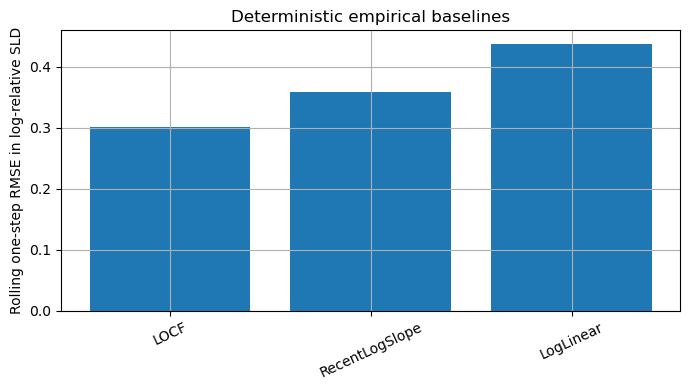

Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_04_cohort_scale_baselines\plots\deterministic_empirical_baseline_rmse.png


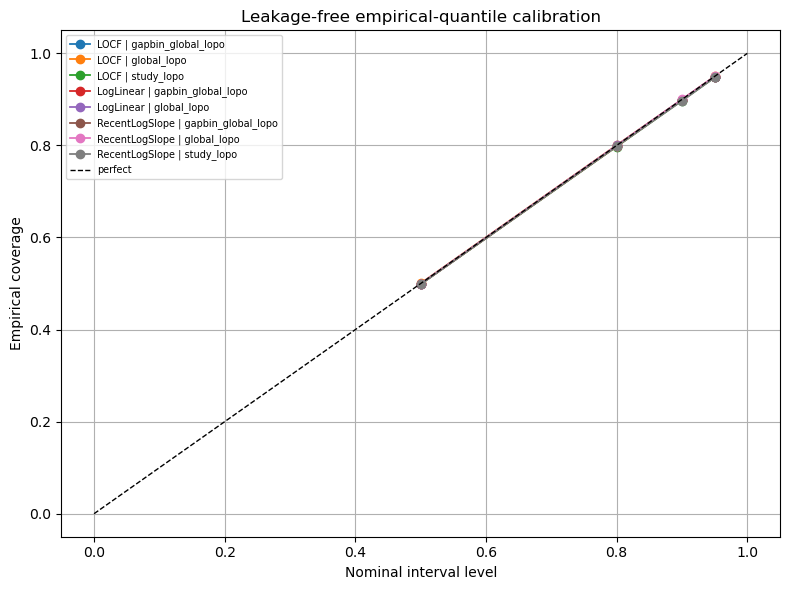

Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_04_cohort_scale_baselines\plots\leakage_free_empirical_calibration_curves.png


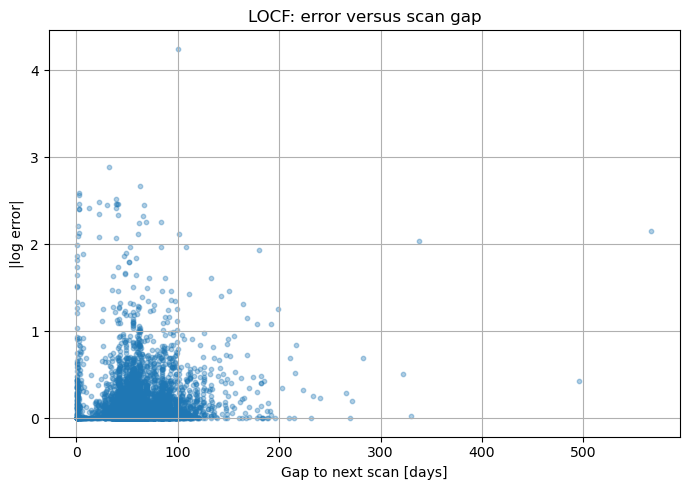

Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_04_cohort_scale_baselines\plots\best_deterministic_error_vs_scan_gap.png


In [11]:
# ---------------------------------------------------------------------
# Plots: deterministic performance and calibration curves
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 4))
plot_df = det_summary.sort_values("rmse")
ax.bar(plot_df["model"], plot_df["rmse"])
ax.set_ylabel("Rolling one-step RMSE in log-relative SLD")
ax.set_title("Deterministic empirical baselines")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
path = PLOT_DIR / "deterministic_empirical_baseline_rmse.png"
fig.savefig(path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", path)

# Calibration curve for top empirical rows.
top_cal = empirical_rank.head(8).copy()
curve_rows = []
for _, row in top_cal.iterrows():
    label = f"{row['model']} | {row['calibration_scope']}"
    for level in INTERVAL_LEVELS:
        pct = int(level * 100)
        curve_rows.append({"label": label, "nominal": level, "empirical": row[f"coverage_{pct}"]})
curve_df = pd.DataFrame(curve_rows)

fig, ax = plt.subplots(figsize=(8, 6))
for label, g in curve_df.groupby("label"):
    ax.plot(g["nominal"], g["empirical"], marker="o", linewidth=1.3, label=label)
ax.plot([0, 1], [0, 1], "k--", linewidth=1.0, label="perfect")
ax.set_xlabel("Nominal interval level")
ax.set_ylabel("Empirical coverage")
ax.set_title("Leakage-free empirical-quantile calibration")
ax.legend(fontsize=7)
fig.tight_layout()
path = PLOT_DIR / "leakage_free_empirical_calibration_curves.png"
fig.savefig(path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", path)

# Residual vs scan gap for official best deterministic model.
g = baseline_roll[baseline_roll["model"] == BEST_DET_MODEL].copy()
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(g["gap_days"], g["abs_log_error"], s=10, alpha=0.35)
ax.set_xlabel("Gap to next scan [days]")
ax.set_ylabel("|log error|")
ax.set_title(f"{BEST_DET_MODEL}: error versus scan gap")
fig.tight_layout()
path = PLOT_DIR / "best_deterministic_error_vs_scan_gap.png"
fig.savefig(path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", path)

## SBI readiness table

The goal is not just to find a forecasting baseline. We also need to decide where SBI should start.

A stratum is more SBI-ready if it has:

- enough patients;
- enough rolling-origin prediction events;
- dose histories for most patients;
- enough scan timepoints per patient;
- a coherent drug signature or study context;
- baseline forecast/calibration performance that can be clearly reported.

The readiness flags below are heuristic. They are meant to choose the next modeling experiments, not to make clinical claims.

In [12]:
# ---------------------------------------------------------------------
# SBI readiness by study/drug/arm stratum
# ---------------------------------------------------------------------

def readiness_level(row: pd.Series) -> str:
    n_patients = row["n_patients"]
    n_predictions = row["n_predictions"]
    dose_frac = row["dose_available_frac"]
    median_scans = row["median_n_scans"]

    if n_patients >= 80 and n_predictions >= 200 and dose_frac >= 0.80 and median_scans >= 6:
        return "green"
    if n_patients >= 30 and n_predictions >= 80 and median_scans >= 5:
        return "yellow"
    return "red"


def readiness_reason(row: pd.Series) -> str:
    reasons = []
    if row["n_patients"] < 30:
        reasons.append("few_patients")
    if row["n_predictions"] < 80:
        reasons.append("few_prediction_events")
    if row["dose_available_frac"] < 0.80:
        reasons.append("limited_dose_rows")
    if row["median_n_scans"] < 5:
        reasons.append("few_scans")
    if not reasons:
        reasons.append("sufficient_for_next_experiment")
    return ";".join(reasons)


stratum_features = (
    cohort.groupby(["study_id", "drug_signature", "arm", "model_family_hint"])
    .agg(
        n_patients=("patient_key", "nunique"),
        median_n_scans=("n_scans", "median"),
        median_duration_days=("duration_days", "median"),
        median_gap_days=("median_gap_days", "median"),
        dose_available_frac=("n_dose_rows", lambda x: float(np.mean(np.asarray(x) > 0))),
        response_then_regrowth_frac=("response_class", lambda x: float(np.mean(np.asarray(x) == "response_then_regrowth"))),
        response_or_shrinkage_frac=("response_class", lambda x: float(np.mean(np.asarray(x) == "response_or_shrinkage"))),
        progression_or_growth_frac=("response_class", lambda x: float(np.mean(np.asarray(x) == "progression_or_growth"))),
    )
    .reset_index()
)

perf_by_stratum = (
    best_calibrated_rows.groupby(["study_id", "drug_signature", "arm", "model_family_hint"])
    .agg(
        n_predictions=("log_error", "count"),
        baseline_rmse=("squared_log_error", lambda x: float(np.sqrt(np.mean(x)))),
        baseline_median_abs_log_error=("abs_log_error", "median"),
        baseline_coverage_80=("covered_80", "mean"),
        baseline_coverage_90=("covered_90", "mean"),
        baseline_width_log_80=("width_log_80", "median"),
    )
    .reset_index()
)

readiness = stratum_features.merge(perf_by_stratum, on=["study_id", "drug_signature", "arm", "model_family_hint"], how="left")
readiness["n_predictions"] = readiness["n_predictions"].fillna(0).astype(int)
readiness["sbi_readiness"] = readiness.apply(readiness_level, axis=1)
readiness["readiness_reason"] = readiness.apply(readiness_reason, axis=1)

order = {"green": 0, "yellow": 1, "red": 2}
readiness["_order"] = readiness["sbi_readiness"].map(order)
readiness = readiness.sort_values(["_order", "n_patients", "n_predictions"], ascending=[True, False, False]).drop(columns="_order")

readiness_path = OUT_DIR / "sbi_readiness_by_study_drug_arm.csv"
readiness.to_csv(readiness_path, index=False)

print("Saved:", readiness_path)
display(readiness.head(50))

print("Readiness counts:")
display(readiness["sbi_readiness"].value_counts().to_frame("n_strata"))

Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_04_cohort_scale_baselines\sbi_readiness_by_study_drug_arm.csv


,study_id,drug_signature,arm,model_family_hint,n_patients,median_n_scans,median_duration_days,median_gap_days,dose_available_frac,response_then_regrowth_frac,response_or_shrinkage_frac,progression_or_growth_frac,n_predictions,baseline_rmse,baseline_median_abs_log_error,baseline_coverage_80,baseline_coverage_90,baseline_width_log_80,sbi_readiness,readiness_reason
22,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,anti_angiogenic_or_vascular_support_model,268,6.0,362.0,64.00,1.0,0.324627,0.458955,0.018657,772,0.297332,0.110457,0.814767,0.931347,0.519931,green,sufficient_for_next_experiment
25,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,FOLFOX alone,cytotoxic_transit_damage_TGI,190,7.0,372.5,57.50,1.0,0.457895,0.389474,0.042105,907,0.361455,0.102370,0.780595,0.890849,0.519931,green,sufficient_for_next_experiment
27,EFC10262,5-FU+IRINOTECAN+LEUCOVORIN+PLACEBO,Placebo + FOLFIRI regimen,cytotoxic_transit_damage_TGI,190,8.0,302.0,42.00,1.0,0.231579,0.184211,0.184211,850,0.357746,0.065803,0.870588,0.931765,0.520053,green,sufficient_for_next_experiment
26,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,Panitumumab + FOLFOX,cytotoxic_transit_damage_TGI,188,8.0,420.0,57.00,1.0,0.452128,0.430851,0.021277,982,0.373710,0.115288,0.754582,0.866599,0.519751,green,sufficient_for_next_experiment
24,DATASET_263,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,Panitumumab + FOLFIRI,cytotoxic_transit_damage_TGI,152,7.0,359.0,56.00,1.0,0.460526,0.282895,0.111842,646,0.305638,0.102753,0.806502,0.914861,0.519931,green,sufficient_for_next_experiment
2,A6181122,FLUOROURACIL+FOLINIC ACID/VITAMIN K+IRINOTECAN...,UNKNOWN_ARM,cytotoxic_transit_damage_TGI,127,8.0,338.0,43.00,1.0,0.330709,0.354331,0.031496,593,0.330668,0.093786,0.836425,0.910624,0.520040,green,sufficient_for_next_experiment
32,EFC5505,5-FU BOLUS+5-FU INFUSION+LEUCOVORIN+OXALIPLATI...,PLACEBO,cytotoxic_transit_damage_TGI,120,7.0,365.0,61.00,1.0,0.300000,0.525000,0.050000,365,0.498425,0.131535,0.775342,0.876712,0.519931,green,sufficient_for_next_experiment
23,DATASET_263,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,FOLFIRI alone,cytotoxic_transit_damage_TGI,104,7.0,328.5,56.50,1.0,0.298077,0.182692,0.163462,388,0.335119,0.090526,0.811856,0.907216,0.519931,green,sufficient_for_next_experiment
20,AMGEN_20050203,NO_DOSE_ROWS,FOLFOX alone,unknown_drug_baseline_only,93,7.0,351.0,57.00,0.0,0.430108,0.462366,0.043011,388,0.309127,0.119409,0.845361,0.920103,0.520053,yellow,limited_dose_rows
21,AMGEN_20050203,NO_DOSE_ROWS,Panitumumab + FOLFOX,unknown_drug_baseline_only,78,8.0,366.0,56.50,0.0,0.358974,0.551282,0.025641,371,0.356523,0.113575,0.789757,0.870620,0.519796,yellow,limited_dose_rows


Readiness counts:


,n_strata
sbi_readiness,
red,17
green,8
yellow,8


In [13]:
# ---------------------------------------------------------------------
# Recommended SBI starter cohorts
# ---------------------------------------------------------------------

starter = readiness[readiness["sbi_readiness"].isin(["green", "yellow"])].copy()
starter = starter.sort_values(["sbi_readiness", "dose_available_frac", "n_patients", "n_predictions"], ascending=[True, False, False, False])

starter_path = OUT_DIR / "recommended_sbi_starter_strata.csv"
starter.to_csv(starter_path, index=False)

display(starter.head(25))
print("Saved:", starter_path)

if len(starter):
    top = starter.iloc[0]
    top_patients = cohort[
        (cohort["study_id"] == top["study_id"])
        & (cohort["drug_signature"] == top["drug_signature"])
        & (cohort["arm"] == top["arm"])
    ].copy()

    top_patients_path = OUT_DIR / "top_recommended_sbi_starter_patients.csv"
    top_patients.to_csv(top_patients_path, index=False)

    print("Top starter stratum:")
    print(top[["study_id", "drug_signature", "arm", "model_family_hint", "n_patients", "n_predictions", "sbi_readiness"]].to_dict())
    print("Saved:", top_patients_path)
    display(top_patients.head(30))
else:
    print("No green/yellow starter strata under current criteria. Loosen thresholds or curate drug classes.")

,study_id,drug_signature,arm,model_family_hint,n_patients,median_n_scans,median_duration_days,median_gap_days,dose_available_frac,response_then_regrowth_frac,response_or_shrinkage_frac,progression_or_growth_frac,n_predictions,baseline_rmse,baseline_median_abs_log_error,baseline_coverage_80,baseline_coverage_90,baseline_width_log_80,sbi_readiness,readiness_reason
22,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,anti_angiogenic_or_vascular_support_model,268,6.0,362.0,64.00,1.0,0.324627,0.458955,0.018657,772,0.297332,0.110457,0.814767,0.931347,0.519931,green,sufficient_for_next_experiment
25,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,FOLFOX alone,cytotoxic_transit_damage_TGI,190,7.0,372.5,57.50,1.0,0.457895,0.389474,0.042105,907,0.361455,0.102370,0.780595,0.890849,0.519931,green,sufficient_for_next_experiment
27,EFC10262,5-FU+IRINOTECAN+LEUCOVORIN+PLACEBO,Placebo + FOLFIRI regimen,cytotoxic_transit_damage_TGI,190,8.0,302.0,42.00,1.0,0.231579,0.184211,0.184211,850,0.357746,0.065803,0.870588,0.931765,0.520053,green,sufficient_for_next_experiment
26,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,Panitumumab + FOLFOX,cytotoxic_transit_damage_TGI,188,8.0,420.0,57.00,1.0,0.452128,0.430851,0.021277,982,0.373710,0.115288,0.754582,0.866599,0.519751,green,sufficient_for_next_experiment
24,DATASET_263,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,Panitumumab + FOLFIRI,cytotoxic_transit_damage_TGI,152,7.0,359.0,56.00,1.0,0.460526,0.282895,0.111842,646,0.305638,0.102753,0.806502,0.914861,0.519931,green,sufficient_for_next_experiment
2,A6181122,FLUOROURACIL+FOLINIC ACID/VITAMIN K+IRINOTECAN...,UNKNOWN_ARM,cytotoxic_transit_damage_TGI,127,8.0,338.0,43.00,1.0,0.330709,0.354331,0.031496,593,0.330668,0.093786,0.836425,0.910624,0.520040,green,sufficient_for_next_experiment
32,EFC5505,5-FU BOLUS+5-FU INFUSION+LEUCOVORIN+OXALIPLATI...,PLACEBO,cytotoxic_transit_damage_TGI,120,7.0,365.0,61.00,1.0,0.300000,0.525000,0.050000,365,0.498425,0.131535,0.775342,0.876712,0.519931,green,sufficient_for_next_experiment
23,DATASET_263,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,FOLFIRI alone,cytotoxic_transit_damage_TGI,104,7.0,328.5,56.50,1.0,0.298077,0.182692,0.163462,388,0.335119,0.090526,0.811856,0.907216,0.519931,green,sufficient_for_next_experiment
31,EFC4972,5-FU BOLUS+5-FU INFUSION+LEUCOVORIN+OXALIPLATIN,PLACEBO,cytotoxic_transit_damage_TGI,74,7.0,352.0,61.00,1.0,0.432432,0.391892,0.027027,220,0.705271,0.193146,0.586364,0.736364,0.519661,yellow,sufficient_for_next_experiment
11,AMGEN_20040249,5-FLUOROURACIL 46 HOUR+5-FLUOROURACIL BOLUS+BE...,bevacizumab with chemotherapy,anti_angiogenic_or_vascular_support_model,67,7.0,497.0,84.00,1.0,0.283582,0.582090,0.044776,240,0.227807,0.122271,0.841667,0.950000,0.519931,yellow,sufficient_for_next_experiment


Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_04_cohort_scale_baselines\recommended_sbi_starter_strata.csv
Top starter stratum:
{'study_id': 'CEDIRANIB_HORIZONIII', 'drug_signature': 'FOLFOX + BEVACIZUMAB 5MG/KG', 'arm': 'FOLFOX + bevacizumab 5mg/kg', 'model_family_hint': 'anti_angiogenic_or_vascular_support_model', 'n_patients': 268, 'n_predictions': 772, 'sbi_readiness': 'green'}
Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_04_cohort_scale_baselines\top_recommended_sbi_starter_patients.csv


,study_id,patient_id,patient_key,arm,n_scans,duration_days,first_raw_time_days,last_raw_time_days,median_gap_days,max_gap_days,...,response_class,n_collapsed_duplicate_rows,eligible_basic,n_dose_rows,n_drugs,drug_signature,dose_time_min,dose_time_max,dose_span_days,model_family_hint
66,CEDIRANIB_HORIZONIII,337.0,CEDIRANIB_HORIZONIII__337.0,FOLFOX + bevacizumab 5mg/kg,14,933.0,-13.0,920.0,63.0,110.0,...,response_or_shrinkage,0,True,162,1,FOLFOX + BEVACIZUMAB 5MG/KG,0.0,952.0,952.0,anti_angiogenic_or_vascular_support_model
74,CEDIRANIB_HORIZONIII,235.0,CEDIRANIB_HORIZONIII__235.0,FOLFOX + bevacizumab 5mg/kg,14,754.0,-7.0,747.0,56.0,91.0,...,response_or_shrinkage,0,True,100,1,FOLFOX + BEVACIZUMAB 5MG/KG,0.0,754.0,754.0,anti_angiogenic_or_vascular_support_model
101,CEDIRANIB_HORIZONIII,592.0,CEDIRANIB_HORIZONIII__592.0,FOLFOX + bevacizumab 5mg/kg,13,678.0,-6.0,672.0,56.5,62.0,...,response_then_regrowth,0,True,208,1,FOLFOX + BEVACIZUMAB 5MG/KG,0.0,721.0,721.0,anti_angiogenic_or_vascular_support_model
125,CEDIRANIB_HORIZONIII,251.0,CEDIRANIB_HORIZONIII__251.0,FOLFOX + bevacizumab 5mg/kg,12,853.0,-13.0,840.0,84.0,85.0,...,stable_like,0,True,80,1,FOLFOX + BEVACIZUMAB 5MG/KG,0.0,629.0,629.0,anti_angiogenic_or_vascular_support_model
177,CEDIRANIB_HORIZONIII,382.0,CEDIRANIB_HORIZONIII__382.0,FOLFOX + bevacizumab 5mg/kg,11,773.0,-7.0,766.0,83.5,92.0,...,response_or_shrinkage,0,True,158,1,FOLFOX + BEVACIZUMAB 5MG/KG,0.0,630.0,630.0,anti_angiogenic_or_vascular_support_model
179,CEDIRANIB_HORIZONIII,23.0,CEDIRANIB_HORIZONIII__23.0,FOLFOX + bevacizumab 5mg/kg,11,748.0,-26.0,722.0,79.5,91.0,...,response_then_regrowth,0,True,176,1,FOLFOX + BEVACIZUMAB 5MG/KG,0.0,714.0,714.0,anti_angiogenic_or_vascular_support_model
248,CEDIRANIB_HORIZONIII,234.0,CEDIRANIB_HORIZONIII__234.0,FOLFOX + bevacizumab 5mg/kg,10,730.0,-5.0,725.0,84.0,105.0,...,response_then_regrowth,0,True,171,1,FOLFOX + BEVACIZUMAB 5MG/KG,0.0,714.0,714.0,anti_angiogenic_or_vascular_support_model
249,CEDIRANIB_HORIZONIII,109.0,CEDIRANIB_HORIZONIII__109.0,FOLFOX + bevacizumab 5mg/kg,10,696.0,-23.0,673.0,81.0,92.0,...,response_then_regrowth,0,True,172,1,FOLFOX + BEVACIZUMAB 5MG/KG,0.0,616.0,616.0,anti_angiogenic_or_vascular_support_model
251,CEDIRANIB_HORIZONIII,546.0,CEDIRANIB_HORIZONIII__546.0,FOLFOX + bevacizumab 5mg/kg,10,692.0,-4.0,688.0,84.0,91.0,...,response_or_shrinkage,0,True,163,1,FOLFOX + BEVACIZUMAB 5MG/KG,0.0,702.0,702.0,anti_angiogenic_or_vascular_support_model
256,CEDIRANIB_HORIZONIII,508.0,CEDIRANIB_HORIZONIII__508.0,FOLFOX + bevacizumab 5mg/kg,10,669.0,-7.0,662.0,71.0,118.0,...,response_or_shrinkage,0,True,153,1,FOLFOX + BEVACIZUMAB 5MG/KG,0.0,659.0,659.0,anti_angiogenic_or_vascular_support_model


## Interpretation guide

This notebook is deliberately conservative.

If `LOCF` or `RecentLogSlope` remain the best broad baselines, this does **not** mean mechanistic models are useless. It means:

```text
short-term scan-to-scan prediction is dominated by local persistence
```

Mechanistic/SBI models should then be evaluated on tasks where they can add value:

1. calibrated posterior predictive intervals;
2. long-horizon scenario forecasts;
3. response/regrowth subtype explanation;
4. drug-specific simulation;
5. posterior over latent biological parameters;
6. virtual patient generation.

The key output of this notebook is the **baseline contract**:

> Any future SBI model should beat the leakage-free empirical baseline in NLL, coverage/width tradeoff, or clinically relevant long-horizon prediction.

In [14]:
# ---------------------------------------------------------------------
# Save final conclusion
# ---------------------------------------------------------------------

best_gaussian = gaussian_rank.iloc[0].to_dict() if len(gaussian_rank) else {}
best_empirical = empirical_rank.iloc[0].to_dict() if len(empirical_rank) else {}


def json_safe_dict(d: dict) -> dict:
    out = {}
    for k, v in d.items():
        if isinstance(v, (np.integer,)):
            out[k] = int(v)
        elif isinstance(v, (np.floating, float)):
            out[k] = float(v) if np.isfinite(v) else None
        elif isinstance(v, (np.bool_, bool)):
            out[k] = bool(v)
        else:
            out[k] = v
    return out


conclusion = {
    "n_patients_in_feature_table": int(patient_features["patient_key"].nunique()) if "patient_key" in patient_features else int(len(patient_features)),
    "n_patients_in_forecasting_cohort": int(cohort["patient_key"].nunique()),
    "n_rolling_prediction_rows": int(len(baseline_roll)),
    "min_scans": int(MIN_SCANS),
    "min_duration_days": float(MIN_DURATION_DAYS),
    "min_train_scans": int(MIN_TRAIN_SCANS),
    "best_deterministic_model": BEST_DET_MODEL,
    "deterministic_summary": [json_safe_dict(x) for x in det_summary.to_dict(orient="records")],
    "best_gaussian_calibration": json_safe_dict(best_gaussian),
    "best_empirical_interval_calibration": json_safe_dict(best_empirical),
    "readiness_counts": {str(k): int(v) for k, v in readiness["sbi_readiness"].value_counts().to_dict().items()},
    "top_recommended_sbi_strata": [json_safe_dict(x) for x in starter.head(10).to_dict(orient="records")] if len(starter) else [],
    "recommended_next_action": (
        "Use this leakage-free empirical baseline as the official baseline. "
        "Start SBI only on green/yellow drug-study strata, and evaluate SBI by "
        "posterior predictive calibration, NLL, interval width, and long-horizon behavior."
    ),
}

conclusion_path = OUT_DIR / "cohort_scale_baseline_and_sbi_readiness_conclusion.json"
with open(conclusion_path, "w") as f:
    json.dump(conclusion, f, indent=2)

print(json.dumps(conclusion, indent=2)[:8000])
print("Saved:", conclusion_path)

{
  "n_patients_in_feature_table": 5862,
  "n_patients_in_forecasting_cohort": 1923,
  "n_rolling_prediction_rows": 23130,
  "min_scans": 6,
  "min_duration_days": 90.0,
  "min_train_scans": 4,
  "best_deterministic_model": "LOCF",
  "deterministic_summary": [
    {
      "model": "LOCF",
      "count": 7710,
      "n_patients": 1923,
      "median_abs_log_error": 0.06754542522693255,
      "mean_abs_log_error": 0.14925324780441734,
      "rmse": 0.30152140726939447,
      "median_gap_days": 56.0
    },
    {
      "model": "RecentLogSlope",
      "count": 7710,
      "n_patients": 1923,
      "median_abs_log_error": 0.1052087891296945,
      "mean_abs_log_error": 0.19686489824074999,
      "rmse": 0.35905720509412364,
      "median_gap_days": 56.0
    },
    {
      "model": "LogLinear",
      "count": 7710,
      "n_patients": 1923,
      "median_abs_log_error": 0.22376339601105413,
      "mean_abs_log_error": 0.30138069785739674,
      "rmse": 0.4375505807804349,
      "median_gap_d

# What to do after this notebook

Use the output files from this notebook to decide the next branch.

## Branch A — if a green/yellow drug-specific stratum exists

Create a focused synthetic SBI notebook for that stratum:

```text
05_synthetic_sbi_for_selected_drug_stratum.ipynb
```

That notebook should simulate realistic scan schedules and observation noise copied from the selected stratum, not from an abstract toy schedule.

## Branch B — if no stratum is green/yellow

Do not train SBI yet. Instead:

```text
05_drug_metadata_and_model_family_curation.ipynb
```

Curate drug classes, line of therapy, combination flags, and mechanism-specific model families.

## Branch C — if empirical calibration is strong but mechanistic prediction remains weak

Build a hybrid model:

```text
05_hybrid_empirical_mechanistic_features.ipynb
```

Use mechanistic model summaries as features, not as direct point forecasters.

Recommended default after this notebook:

```text
05_synthetic_sbi_for_selected_drug_stratum.ipynb
```

but only for the best-supported stratum identified here.